In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import joblib

In [2]:
# working_dir = "C:/Users/aless/Desktop/UNIBO_local/PhD_lessons/machine_learning/RF_tp_extreme_SEAS5/data/preprocessed_data" 
working_dir = "./data/processed"
mslp = xr.open_dataset(f"{working_dir}/mslp.nc")


In [4]:
mslp.info()

xarray.Dataset {
dimensions:
	lat = 41 ;
	lon = 51 ;
	id = 159575 ;

variables:
	float32 msl(lat, lon, id) ;
		msl:GRIB_paramId = 151 ;
		msl:GRIB_dataType = fc ;
		msl:GRIB_numberOfPoints = 2091 ;
		msl:GRIB_typeOfLevel = surface ;
		msl:GRIB_stepUnits = 1 ;
		msl:GRIB_stepType = instant ;
		msl:GRIB_gridType = regular_ll ;
		msl:GRIB_uvRelativeToGrid = 0 ;
		msl:GRIB_NV = 0 ;
		msl:GRIB_Nx = 51 ;
		msl:GRIB_Ny = 41 ;
		msl:GRIB_cfName = air_pressure_at_mean_sea_level ;
		msl:GRIB_cfVarName = msl ;
		msl:GRIB_gridDefinitionDescription = Latitude/Longitude Grid ;
		msl:GRIB_iDirectionIncrementInDegrees = 1.0 ;
		msl:GRIB_iScansNegatively = 0 ;
		msl:GRIB_jDirectionIncrementInDegrees = 1.0 ;
		msl:GRIB_jPointsAreConsecutive = 0 ;
		msl:GRIB_jScansPositively = 0 ;
		msl:GRIB_latitudeOfFirstGridPointInDegrees = 30.0 ;
		msl:GRIB_latitudeOfLastGridPointInDegrees = -10.0 ;
		msl:GRIB_longitudeOfFirstGridPointInDegrees = -30.0 ;
		msl:GRIB_longitudeOfLastGridPointInDegrees = 20.0 ;
		msl:GRI

# Primo tentativo di PCA
preciso che questo workflow me l'ha proposto gemini, ma sembra una prassi necessaria.
In the EOF decomposition, it is rucial to compensate the area reduction of the grid cells towards the poles, by computing the squared root of cosine of the latitude. Moreover, we compute the anomalies along the dimensions of the data, for every gridpoint. 

In [20]:
mslp_clim

<xarray.DataArray 'msl' (lat: 41, lon: 51)> Size: 8kB
array([[102437.375, 102422.805, 102407.8  , ..., 101438.6  , 101383.04 ,
        101333.266],
       [102406.92 , 102393.695, 102379.055, ..., 101397.125, 101365.555,
        101343.19 ],
       [102378.41 , 102366.07 , 102351.914, ..., 101395.95 , 101355.086,
        101321.6  ],
       ...,
       [101486.12 , 101485.484, 101485.86 , ..., 101290.37 , 101352.664,
        101327.055],
       [101514.51 , 101512.336, 101513.555, ..., 101309.734, 101368.58 ,
        101367.83 ],
       [101550.83 , 101549.82 , 101550.66 , ..., 101365.516, 101383.81 ,
        101415.93 ]], shape=(41, 51), dtype=float32)
Coordinates:
  * lat      (lat) float64 328B 30.0 29.0 28.0 27.0 ... -7.0 -8.0 -9.0 -10.0
  * lon      (lon) float64 408B -30.0 -29.0 -28.0 -27.0 ... 17.0 18.0 19.0 20.0
Attributes: (12/33)
    GRIB_paramId:                             151
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2091
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    long_name:                                Mean sea level pressure
    units:                                    Pa
    standard_name:                            air_pressure_at_mean_sea_level
    GRIB_surface:                             0.0

In [3]:
# Data weangling is a common practice in climate science when performing PCA on gridded data. 
# The idea is to give more weight to grid points that represent larger areas of the Earth, which typically occur at lower latitudes, 
# and less weight to grid points that represent smaller areas, which typically occur at higher latitudes. 
# This is often done by multiplying the data by the square root of the cosine of the latitude (in radians).

# Compute anomalies, so that the first EOF is not dominated by the climatology of the system.
mslp_clim = mslp['msl'].mean(dim=['id']).compute()
mslp_anomalies = mslp['msl'] - mslp_clim

# Extract latitude and convert in radians, then compute the area weights.
lat_rad = np.deg2rad(mslp['lat'])
weights = np.sqrt(np.cos(lat_rad))

# Apply weights to the anomalies.
mslp_weighted = mslp_anomalies * weights

# Fai lo stack SOLO delle dimensioni spaziali (lat e lon)
mslp_flat = mslp_weighted.stack(
    features=('lat', 'lon')
)

# Assicurati che 'id' sia la prima dimensione (righe = campioni, colonne = feature)
mslp_flat = mslp_flat.transpose('id', 'features')

# OPZIONALE: Se vuoi che la dimensione si chiami esplicitamente 'samples'
# invece di 'id' per pulizia del codice, usa .rename()
# mslp_flat = mslp_flat.rename({'id': 'samples'})


In [5]:
mslp_flat

<xarray.DataArray (id: 159575, features: 2091)> Size: 3GB
array([[ 296.51397323,  286.34275294,  283.09290628, ..., -214.86465107,
        -227.06776   , -168.13775304],
       [  54.67303547,   96.38303607,  138.96547873, ...,  -11.79995666,
         -15.56787975,   21.0336941 ],
       [-114.23174645, -158.13739289, -208.84808736, ..., -213.74822942,
        -229.42465016, -245.41894096],
       ...,
       [-293.25685622, -301.33421559, -307.60852804, ...,  -79.40549023,
          60.47283966,  110.47147338],
       [-393.5876926 , -384.44886207, -376.2987992 , ..., -113.45635072,
         -66.36506506,  -16.11833765],
       [-227.70737646, -230.20110667, -219.02657801, ..., -371.22570624,
        -393.84875062, -357.24717677]], shape=(159575, 2091))
Coordinates:
  * id        (id) int64 1MB 0 1 2 3 4 5 ... 159570 159571 159572 159573 159574
  * features  (features) object 17kB MultiIndex
  * lat       (features) float64 17kB 30.0 30.0 30.0 30.0 ... -10.0 -10.0 -10.0
  * lon       (features) float64 17kB -30.0 -29.0 -28.0 -27.0 ... 18.0 19.0 20.0
Attributes: (12/31)
    GRIB_paramId:                             151
    GRIB_dataType:                            fc
    GRIB_numberOfPoints:                      2091
    GRIB_typeOfLevel:                         surface
    GRIB_stepUnits:                           1
    GRIB_stepType:                            instant
    ...                                       ...
    GRIB_shortName:                           msl
    GRIB_system:                              5
    GRIB_totalNumber:                         0
    GRIB_units:                               Pa
    GRIB_surface:                             0.0
    stored_direction:                         decreasing

In [11]:
from sklearn.decomposition import PCA
import numpy as np
import xarray as xr

# 1. PCA via truncated SVD
print("Esecuzione PCA...")
mslp_pca = PCA(n_components=0.9, random_state=42)
# CORREZIONE 1: Aggiunto .values per passare a scikit-learn una matrice NumPy pura
print("Adattamento del modello PCA...")
PC_raw = mslp_pca.fit_transform(mslp_flat.values) 
EOF_raw = mslp_pca.components_ 

# 2. Normalizzazione (PC adimensionali)
print("Normalizzazione dei PC...")
pc_std = np.sqrt(mslp_pca.explained_variance_)
pcs_norm = PC_raw / pc_std # Input per il Random Forest

# 3. Riportiamo le EOF alle unità fisiche originali (Pascals)
eofs_physical = EOF_raw * pc_std[:, np.newaxis]

# 4. Ricostruzione del DataArray Xarray (ancora pesato)
eofs_da_weighted = xr.DataArray(
    eofs_physical,
    dims=['mode', 'features'],
    coords={
        'mode': np.arange(1, mslp_pca.n_components_ + 1),
        'features': mslp_flat.coords['features']
    }
).unstack('features')

# 5. Rimuoviamo il peso del coseno (Un-weighting)
# Xarray applica automaticamente il vettore 1D 'weights' lungo la dimensione 'lat' 
# della matrice 2D (lat, lon), senza bisogno di fare stack o flatten!
eofs_da = eofs_da_weighted / weights

Esecuzione PCA...
Adattamento del modello PCA...
Normalizzazione dei PC...


In [12]:
mslp_pca.n_components_

np.int64(15)

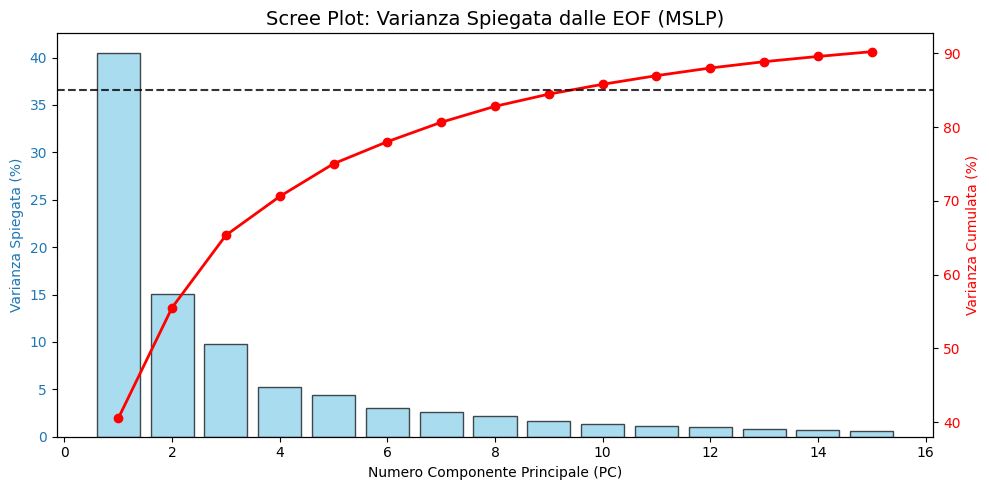

In [13]:
import matplotlib.pyplot as plt
import numpy as np

# Estraiamo la varianza spiegata (in percentuale)
var_exp = mslp_pca.explained_variance_ratio_ * 100
var_cum = np.cumsum(var_exp)
n_components = mslp_pca.n_components_
x_asse = np.arange(1, n_components + 1)

# Creazione del plot
fig, ax1 = plt.subplots(figsize=(10, 5))

# Plot a barre per la varianza della singola componente
ax1.bar(x_asse, var_exp, color='skyblue', edgecolor='black', alpha=0.7, label='Varianza Singola (%)')
ax1.set_xlabel('Numero Componente Principale (PC)')
ax1.set_ylabel('Varianza Spiegata (%)', color='tab:blue')
ax1.tick_params(axis='y', labelcolor='tab:blue')

# Asse gemello per la varianza cumulata
ax2 = ax1.twinx()
ax2.plot(x_asse, var_cum, color='red', marker='o', linestyle='-', linewidth=2, label='Varianza Cumulata (%)')
ax2.set_ylabel('Varianza Cumulata (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Linea orizzontale per la soglia dell'85%
ax2.axhline(85, color='black', linestyle='--', alpha=0.8, label='Soglia 85%')

# Dettagli estetici
plt.title('Scree Plot: Varianza Spiegata dalle EOF (MSLP)', fontsize=14)
fig.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.show()

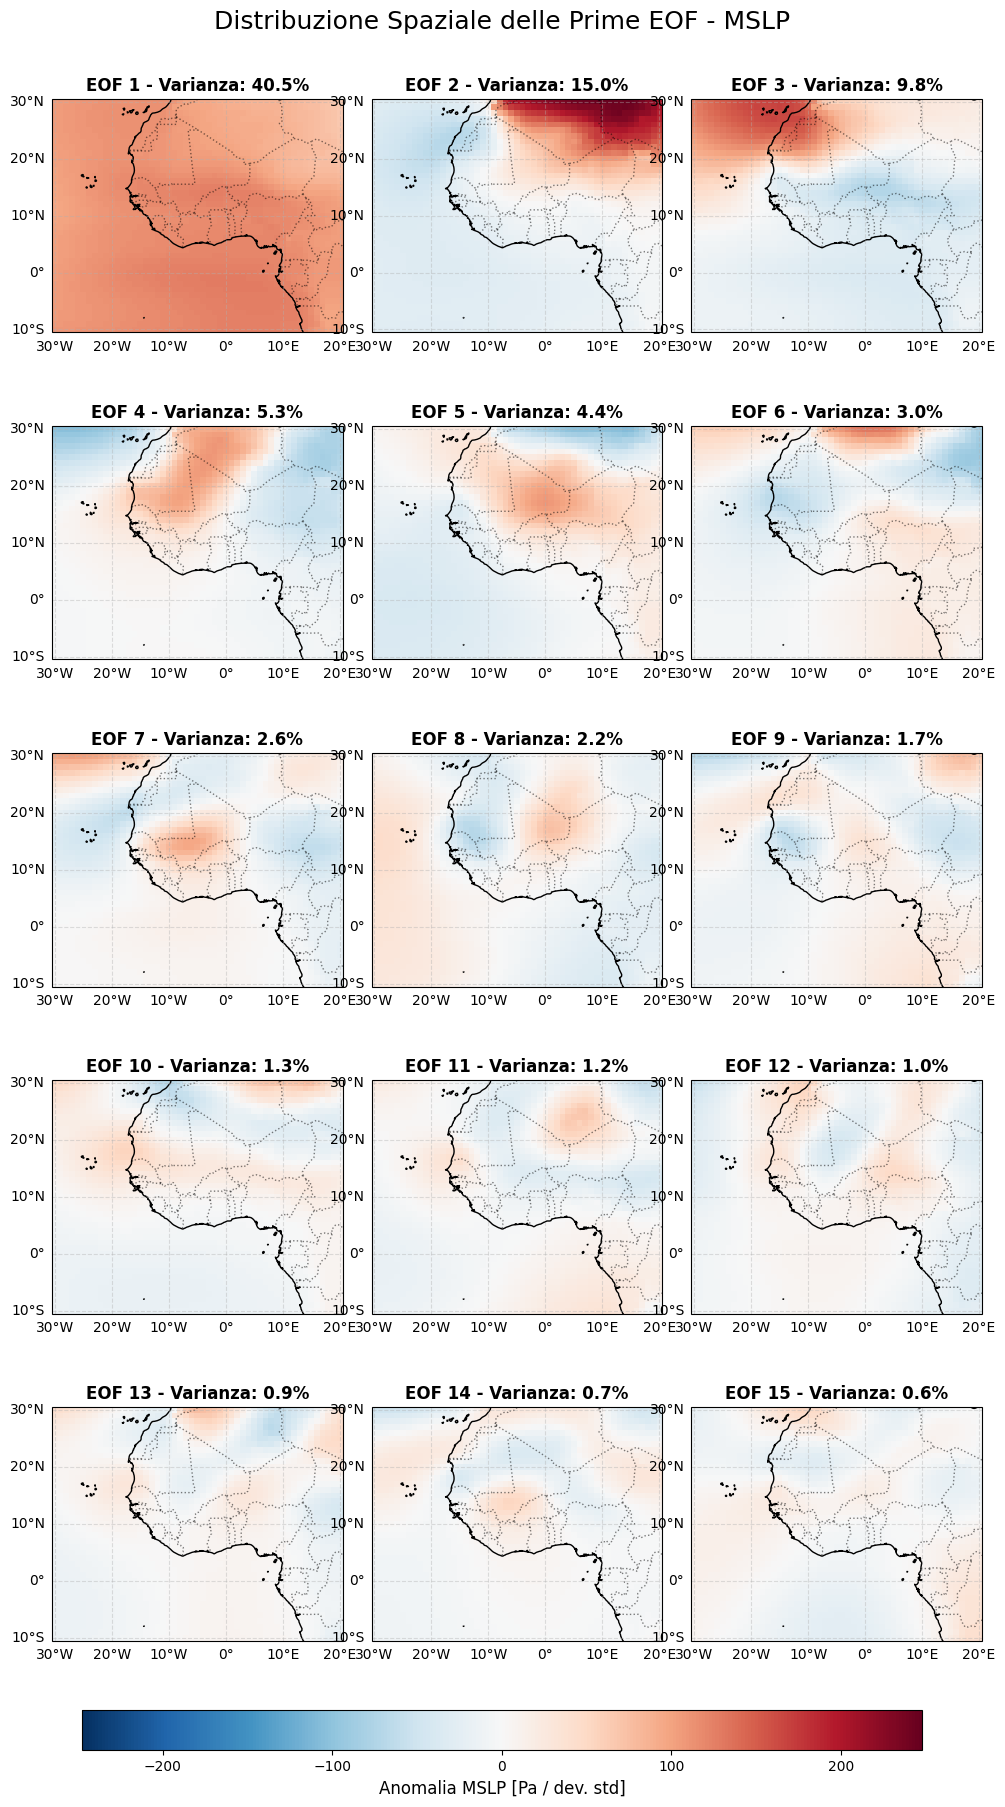

In [19]:
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Determiniamo quanti plot fare (massimo 10, ma se la PCA ne ha trovate meno, usiamo quel numero)
n_plots = min(15, n_components)

# Creiamo una griglia 5x2 di subplots
fig, axes = plt.subplots(
    nrows=5, ncols=3, 
    figsize=(12, 20), 
    subplot_kw={'projection': ccrs.PlateCarree()}
)
axes = axes.flatten() # Appiattiamo l'array degli assi per iterarci comodamente

# Troviamo il valore massimo assoluto per centrare la colorbar in modo simmetrico attorno allo zero
# (Calcolato sulle prime 10 EOF per avere una scala coerente)
vmax = np.abs(eofs_da.isel(mode=slice(0, n_plots))).max().values
vmin = -vmax

for i in range(n_plots):
    ax = axes[i]
    
    # Selezioniamo il modo i-esimo (ricorda che la coordinata 'mode' parte da 1)
    eof_data = eofs_da.sel(mode=i+1)
    
    # Plottiamo la mappa
    mesh = ax.pcolormesh(
        eof_data.lon, eof_data.lat, eof_data,
        transform=ccrs.PlateCarree(),
        cmap='RdBu_r',  # Diverging colormap (Rosso=Anomalia Positiva, Blu=Negativa)
        vmin=vmin, vmax=vmax,
        shading='auto'
    )
    
    # Aggiungiamo dettagli geografici
    ax.coastlines(resolution='50m', linewidth=1)
    ax.add_feature(cfeature.BORDERS, linestyle=':', alpha=0.5)
    
    # Aggiungiamo i gridlines (paralleli e meridiani)
    gl = ax.gridlines(draw_labels=True, linestyle='--', alpha=0.4)
    gl.top_labels = False
    gl.right_labels = False
    
    # Titolo con la percentuale di varianza per facilitare l'interpretazione fisica
    ax.set_title(f'EOF {i+1} - Varianza: {var_exp[i]:.1f}%', fontweight='bold')

# # Nascondiamo eventuali subplot vuoti se n_plots < 10
# for j in range(n_plots, len(axes)):
#     fig.delaxes(axes[j])

# Aggiungiamo un'unica colorbar globale in fondo
cbar_ax = fig.add_axes([0.15, 0.05, 0.7, 0.02]) # [left, bottom, width, height]
cbar = fig.colorbar(mesh, cax=cbar_ax, orientation='horizontal')
cbar.set_label('Anomalia MSLP [Pa / dev. std]', fontsize=12)

# Adattiamo gli spazi (lasciando spazio in basso per la colorbar)
plt.subplots_adjust(bottom=0.1, hspace=0.3, wspace=0.1)
fig.suptitle('Distribuzione Spaziale delle Prime EOF - MSLP', fontsize=18, y=0.92)

plt.show()

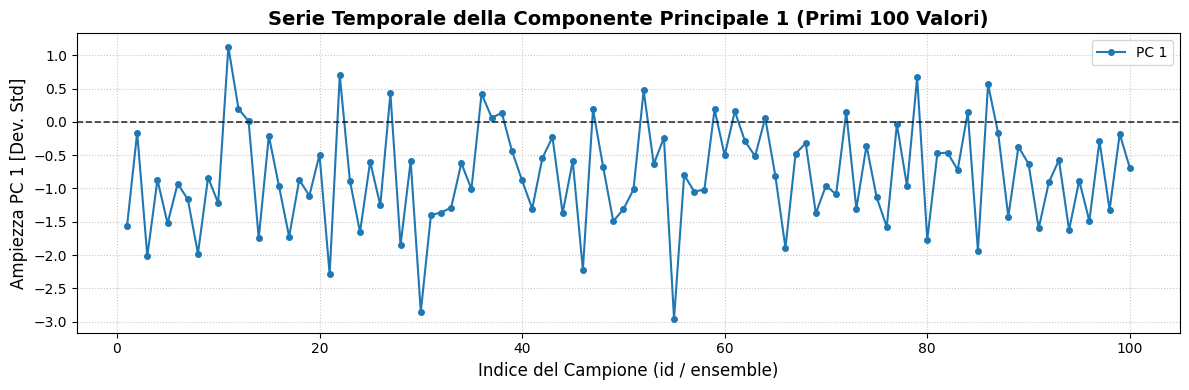

In [21]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Estrazione dei dati (primi 100 campioni, prima colonna)
pc1_100_values = pcs_norm[:100, 0]
x_asse = np.arange(1, 101) # Asse X da 1 a 100

# 2. Creazione del grafico
fig, ax = plt.subplots(figsize=(12, 4))

# Plottiamo la serie temporale
ax.plot(x_asse, pc1_100_values, color='tab:blue', marker='o', markersize=4, 
        linestyle='-', linewidth=1.5, label='PC 1')

# 3. Aggiunta della linea dello zero (Cruciale per l'interpretazione)
ax.axhline(0, color='black', linestyle='--', linewidth=1.2, alpha=0.8)

# 4. Estetica e descrizioni
ax.set_title('Serie Temporale della Componente Principale 1 (Primi 100 Valori)', fontsize=14, fontweight='bold')
ax.set_xlabel('Indice del Campione (id / ensemble)', fontsize=12)
ax.set_ylabel('Ampiezza PC 1 [Dev. Std]', fontsize=12)

# Aggiungiamo una griglia leggera
ax.grid(axis='both', linestyle=':', alpha=0.7)
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()